
# COMP5310 - Project Stage 1
# Dataset B: Air Travel Delay


### STEP - 0 - IMPORTING THE REQUIRED LIBRARIES TO PERFORM EDA AND PLOT THE DATASET

In [51]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt

### STEP - 1 - LOAD DATA

In [52]:
airline_delay_df=pd.read_csv(r'airline_delay.csv')
airline_delay_df

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,31,4,611.0,610,725.0,720,WN,548,...,3.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,18,5,1946.0,1935,2007.0,2010,WN,3770,...,6.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,17,4,1018.0,1020,1102.0,1110,WN,12,...,3.0,9.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,10,4,2057.0,2055,2304.0,2300,WN,74,...,5.0,14.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,15,2,1825.0,18:25,2031.0,2050,WN,2530,...,5.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100995,2008,1,5,6,855.0,900,1000.0,1010,WN,613,...,4.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
100996,2008,1,20,7,1207.0,1205,1306.0,1300,WN,40,...,4.0,11.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
100997,2008,1,26,6,1236.0,1200,1402.0,1335,WN,476,...,5.0,15.0,0,NaN,0,0.0,0.0,0.0,0.0,27.0
100998,2008,1,3,4,1835.0,1755,2035.0,2000,WN,693,...,5.0,11.0,0,NaN,0,9.0,0.0,0.0,0.0,26.0


### STEP - 2.1 - DATA DESCRIPTION

In [53]:
airline_delay_df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,31,4,611.0,610,725.0,720,WN,548,...,3.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,18,5,1946.0,1935,2007.0,2010,WN,3770,...,6.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,17,4,1018.0,1020,1102.0,1110,WN,12,...,3.0,9.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,10,4,2057.0,2055,2304.0,2300,WN,74,...,5.0,14.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,15,2,1825.0,18:25,2031.0,2050,WN,2530,...,5.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [54]:
airline_delay_df.shape

(101000, 29)

### STEP - 2.2 - DATA TYPES

In [55]:
print("\nData Types:\n")
print(airline_delay_df.dtypes)


Data Types:

Year                   int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
DepTime                  str
CRSDepTime               str
ArrTime                  str
CRSArrTime               str
UniqueCarrier            str
FlightNum              int64
TailNum                  str
ActualElapsedTime        str
CRSElapsedTime           str
AirTime                  str
ArrDelay             float64
DepDelay             float64
Origin                   str
Dest                     str
Distance                 str
TaxiIn               float64
TaxiOut              float64
Cancelled                str
CancellationCode         str
Diverted                 str
CarrierDelay         float64
WeatherDelay         float64
NASDelay             float64
SecurityDelay        float64
LateAircraftDelay    float64
dtype: object


#### STEP - 2.3 - LETS CHECK FOR THE MISSING VALUES IN THE DATASET

In [56]:
missing = airline_delay_df.isnull().sum()
missing_percent = (missing / len(airline_delay_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

print("\nMissing Values:\n")
print(missing_df)


Missing Values:

                   Missing Count  Missing %
CancellationCode           99364  98.380198
NASDelay                   81177  80.373267
LateAircraftDelay          81177  80.373267
WeatherDelay               81177  80.373267
CarrierDelay               81177  80.373267
SecurityDelay              81177  80.373267
TailNum                     4146   4.104950
ArrDelay                    3300   3.267327
DepDelay                    3150   3.118812
TaxiIn                      2311   2.288119
TaxiOut                     2153   2.131683
ActualElapsedTime           1310   1.297030
AirTime                     1310   1.297030
ArrTime                     1281   1.268317
DepTime                     1127   1.115842
CRSElapsedTime                 0   0.000000
UniqueCarrier                  0   0.000000
CRSDepTime                     0   0.000000
Month                          0   0.000000
DayofMonth                     0   0.000000
DayOfWeek                      0   0.000000
Year          

#### LETS SEE THE STATISTICAL SUMMARY OF THE DATASET

In [57]:
print("\nNumerical Summary:\n")
print(airline_delay_df.describe())


Numerical Summary:

           Year     Month     DayofMonth      DayOfWeek      FlightNum  \
count  101000.0  101000.0  101000.000000  101000.000000  101000.000000   
mean     2008.0       1.0      17.090366       3.890554    1510.900891   
std         0.0       0.0       8.357797       1.952622    1185.510606   
min      2008.0       1.0       1.000000       1.000000       1.000000   
25%      2008.0       1.0      10.000000       2.000000     502.000000   
50%      2008.0       1.0      17.000000       4.000000    1320.000000   
75%      2008.0       1.0      24.000000       5.000000    2362.000000   
max      2008.0       1.0      31.000000       7.000000    7676.000000   

           ArrDelay      DepDelay        TaxiIn       TaxiOut  CarrierDelay  \
count  97700.000000  97850.000000  98689.000000  98847.000000  19823.000000   
mean       5.711648     10.366050      4.768566     10.926826      9.561671   
std       30.913736     28.335769      2.980770      5.988951     21.798833

#### STEP - 2.4 - LETS CHECK THE UNIQUE VALUES IN THE CATEGORICAL COLUMNS

In [58]:
# Correct dataframe usage + fix warning
categorical_cols = airline_delay_df.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    if col in airline_delay_df.columns:  # safety check
        print(f"\n{col} unique values: {airline_delay_df[col].nunique()}")


DepTime unique values: 2152

CRSDepTime unique values: 711

ArrTime unique values: 2271

CRSArrTime unique values: 952

UniqueCarrier unique values: 10

TailNum unique values: 622

ActualElapsedTime unique values: 581

CRSElapsedTime unique values: 273

AirTime unique values: 579

Origin unique values: 308

Dest unique values: 312

Distance unique values: 769

Cancelled unique values: 6

CancellationCode unique values: 3

Diverted unique values: 6


#### STEP 3 — DATA CLEANING & PROCESSING

#### STEP - 3.1 - Fix data types

In [9]:
numeric_cols = [
    'Distance', 'AirTime', 'ActualElapsedTime',
    'CRSElapsedTime'
]
for col in numeric_cols:
    airline_delay_df[col] = pd.to_numeric(airline_delay_df[col], errors='coerce')

#### STEP - 3.2 - Handle missing values

In [10]:
# Drop rows where target variable is missing
df = airline_delay_df.dropna(subset=['ArrDelay'])

In [11]:
# Departure delay is critical → drop if missing
df = df.dropna(subset=['DepDelay'])

In [12]:
# Fill delay-related missing values with 0 (meaning no delay recorded)
delay_cols = [
    'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay'
]

In [13]:
df[delay_cols] = df[delay_cols].fillna(0)

### STEP - 3.3 - Remove Irrelevant Features
- TailNum is high-cardinality → not useful for modelling
- CancellationCode mostly missing → low value

In [14]:
df = df.drop(columns=['TailNum', 'CancellationCode'], errors='ignore')

### STEP - 3.4 - Handle Outliers (IMPORTANT)
- Cap extreme delays to reduce skew impact

In [15]:
df['ArrDelay'] = np.clip(df['ArrDelay'], -100, 300)
df['DepDelay'] = np.clip(df['DepDelay'], -100, 300)

### STEP - 3.5 - Convert Categorical Features


In [16]:
categorical_cols = ['UniqueCarrier', 'Origin', 'Dest']

for col in categorical_cols:
    df[col] = df[col].astype('category')

### STEP 3.6 - Feature Engineering

In [17]:
df['DelayCategory'] = df['ArrDelay'].apply(
    lambda x: 1 if x > 0 else 0
)

### Weekend indicator

In [18]:
df['IsWeekend'] = df['DayOfWeek'].apply(
    lambda x: 1 if x in [6, 7] else 0
)

### Time-based feature (morning/evening flights)

In [19]:
df['CRSDepTime'] = pd.to_numeric(df['CRSDepTime'], errors='coerce')
df['TimeOfDay'] = df['CRSDepTime'].apply(
    lambda x: 'Morning' if 500 <= x < 1200 else
              'Afternoon' if 1200 <= x < 1700 else
              'Evening'
)

print("Final dataset shape:", df.shape)

Final dataset shape: (95750, 30)


#### STEP - 3.7 - DATA VALIDATION

In [46]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 95750 entries, 0 to 100999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Year               95750 non-null  int64   
 1   Month              95750 non-null  int64   
 2   DayofMonth         95750 non-null  int64   
 3   DayOfWeek          95750 non-null  int64   
 4   DepTime            95750 non-null  str     
 5   CRSDepTime         94538 non-null  float64 
 6   ArrTime            95750 non-null  str     
 7   CRSArrTime         95750 non-null  str     
 8   UniqueCarrier      95750 non-null  category
 9   FlightNum          95750 non-null  int64   
 10  ActualElapsedTime  95249 non-null  float64 
 11  CRSElapsedTime     95273 non-null  float64 
 12  AirTime            95284 non-null  float64 
 13  ArrDelay           95750 non-null  float64 
 14  DepDelay           95750 non-null  float64 
 15  Origin             95750 non-null  category
 16  Dest               

Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
DepTime                 0
CRSDepTime           1212
ArrTime                 0
CRSArrTime              0
UniqueCarrier           0
FlightNum               0
ActualElapsedTime     501
CRSElapsedTime        477
AirTime               466
ArrDelay                0
DepDelay                0
Origin                  0
Dest                    0
Distance              475
TaxiIn                958
TaxiOut               963
Cancelled               0
Diverted                0
CarrierDelay            0
WeatherDelay            0
NASDelay                0
SecurityDelay           0
LateAircraftDelay       0
DelayCategory           0
IsWeekend               0
TimeOfDay               0
dtype: int64

## STEP 4 — EDA

### EDA - Numerical Feature 1 - DepDelay vs ArrDelay


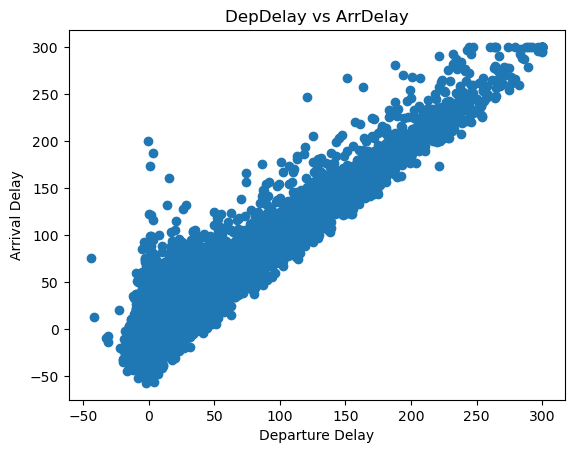

In [21]:
plt.figure()
plt.scatter(df['DepDelay'], df['ArrDelay'])
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.title("DepDelay vs ArrDelay")
plt.show()

### EDA - Numerical Feature 2 - Distance vs ArrDelay

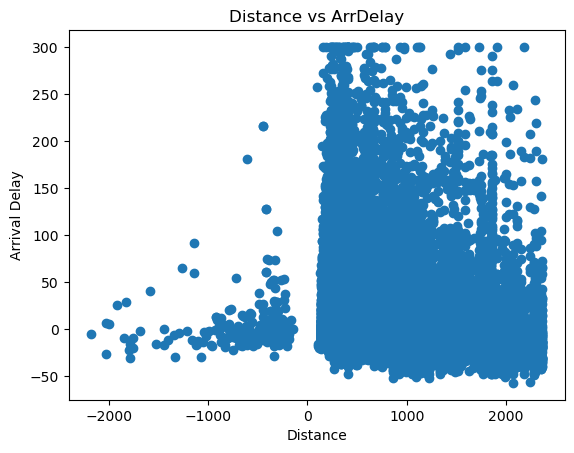

In [22]:
plt.figure()
plt.scatter(df['Distance'], df['ArrDelay'])
plt.xlabel("Distance")
plt.ylabel("Arrival Delay")
plt.title("Distance vs ArrDelay")
plt.show()

### EDA - Categorical Feature 1 - Airline

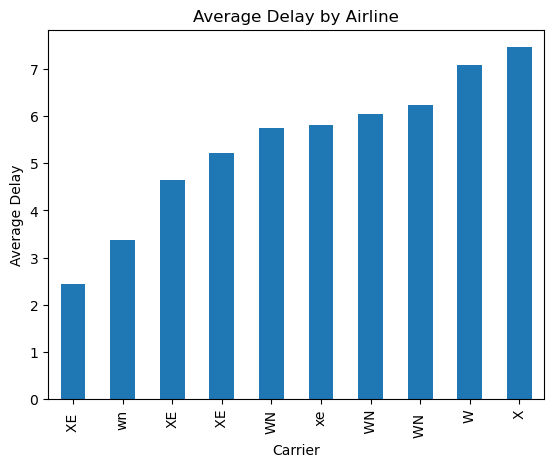

In [48]:
carrier_delay = df.groupby('UniqueCarrier')['ArrDelay'].mean()
plt.figure()
carrier_delay.sort_values().plot(kind='bar')
plt.title("Average Delay by Airline")
plt.xlabel("Carrier")
plt.ylabel("Average Delay")
plt.show()

### EDA - Categorical Feature 2 - Days of week

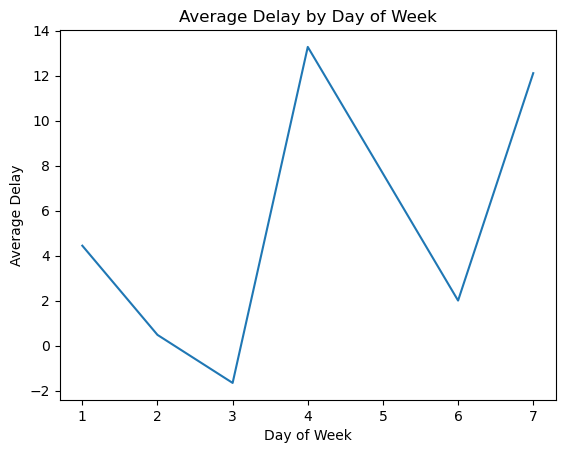

In [49]:
day_delay = df.groupby('DayOfWeek')['ArrDelay'].mean()
plt.figure()
day_delay.plot()
plt.title("Average Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay")
plt.show()

### 4.3 - Correlation Analysis(Numerical Features)

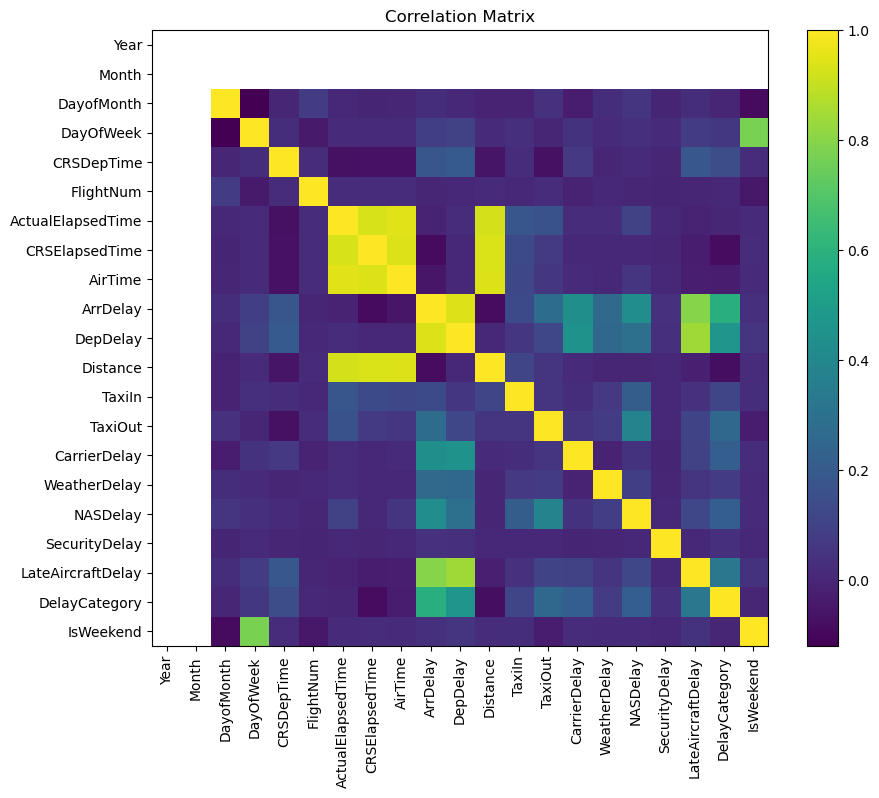

In [50]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation = numeric_df.corr()
plt.figure(figsize=(10,8))
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

### SAVE CLEANED DATASET

In [26]:
df.to_csv("cleaned_airline_delay.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
